<a href="https://colab.research.google.com/github/lailynissaam/Analisis-Deret-Waktu/blob/main/Hands_On_STA2542_Minggu_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> Pendahuluan dan Pengenalan Data Deret Waktu </center></h1>

Point yang dibahas:
- Plot Deret Waktu
- Metode Pemulusan (Smoothing) dengan Single Moving Average (SMA), Double Moving Average (DMA), Single Exponential Smoothing dan Double Exponential Smoothing

In [4]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.3 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.3 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.3 MB 2.2 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.3 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.3 MB 2.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/9.3 MB 2.2 MB/s eta 0:00:03
   --------------------- ------------------ 5.0/9.3 MB 2.2 MB/s eta 0:00:03
   ---------------------- ----------------- 5.2/9.3 MB 2.2 MB/s eta 0:00:02
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#memanggil packages yang dibutuhkan
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings("ignore")

## Deret Curah Hujan Bogor

In [7]:
#memanggil data curah hujan yang tersimpan dalam github
rr=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/curahhujan_agg.csv')

In [8]:
#menampilkan 10 data pertama
rr.head(10)

,tanggal,rr
0,2007-01,12.025806
1,2007-02,15.650000
2,2007-03,8.916129
3,2007-04,15.756667
4,2007-05,6.309677
5,2007-06,9.116667
6,2007-07,4.319355
7,2007-08,7.996774
8,2007-09,6.863333
9,2007-10,7.596774


In [9]:
rr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tanggal  72 non-null     object 
 1   rr       72 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


In [10]:
#mengubah tipe data menjadi datetime
rr.tanggal=pd.to_datetime(rr.tanggal)

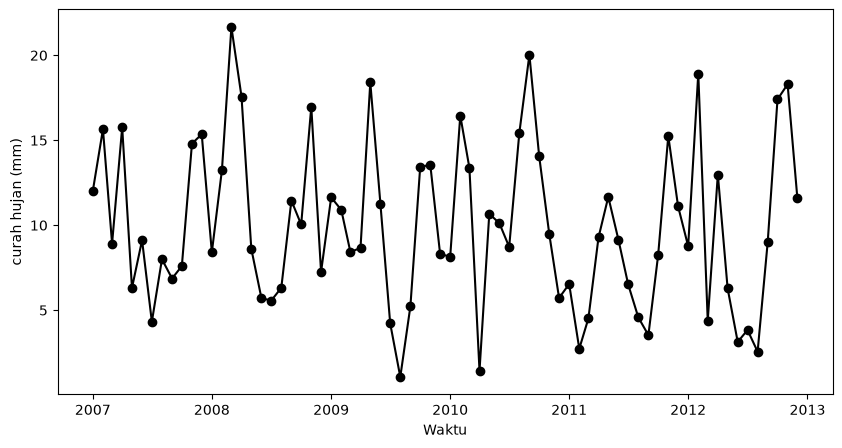

In [11]:
#menampilkan plot deret waktu dari data
plt.figure(figsize=(10,5))
plt.plot(rr.tanggal,rr.rr,'-ok')
plt.xlabel('Waktu'), plt.ylabel('curah hujan (mm)')
plt.show()

Berdasarkan plot deret waktu yang dihasilkan apa yang dapat Anda interpretasikan?

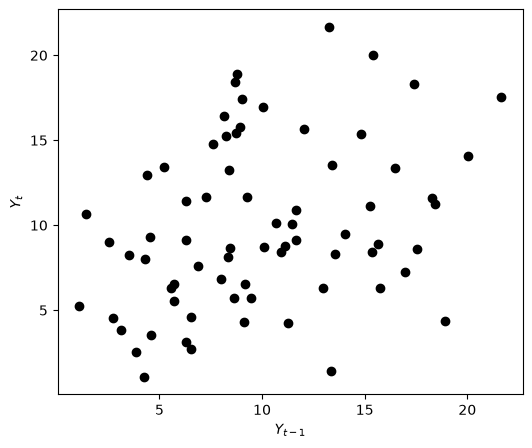

In [12]:
#menampilkan scatter plot antara Yt dan Yt-1
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(rr.rr, lag=1, c='k')
plt.xlabel(r'$Y_{t-1}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Apa yang dapat Anda maknai dari scatterplot tersebut?

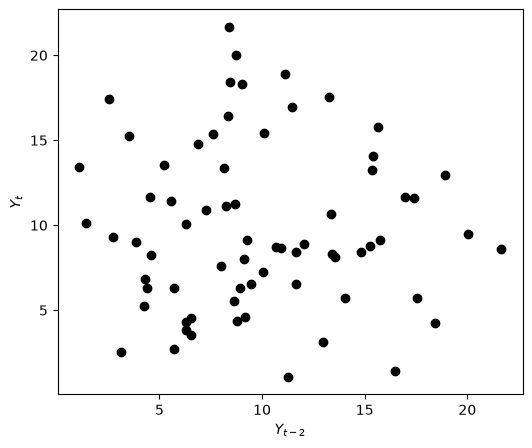

In [13]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(rr.rr, lag=2, c='k')
plt.xlabel(r'$Y_{t-2}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Apa yang dapat Anda maknai dari scatterplot tersebut?

Apa yang dapat Anda simpulkan dari dua scatterplot di atas?

## Deret Harga Saham BNI



In [14]:
#memanggil data harga saham BNI
bni=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/BBNI.JK.csv')

In [16]:
bni.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-10-03,8975.0,9000.0,8825.0,8900.0,8900.0,14174700
1,2022-10-04,8925.0,9000.0,8850.0,8850.0,8850.0,29190100
2,2022-10-05,8900.0,8975.0,8850.0,8850.0,8850.0,32491500
3,2022-10-06,8900.0,8950.0,8800.0,8900.0,8900.0,11984500
4,2022-10-07,8850.0,8875.0,8750.0,8775.0,8775.0,18278000


In [17]:
#memeriksa tipe data
bni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       59 non-null     object 
 1   Open       59 non-null     float64
 2   High       59 non-null     float64
 3   Low        59 non-null     float64
 4   Close      59 non-null     float64
 5   Adj Close  59 non-null     float64
 6   Volume     59 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 3.4+ KB


In [18]:
#mengubah type data menjadi datetime
bni.Date=pd.to_datetime(bni.Date)

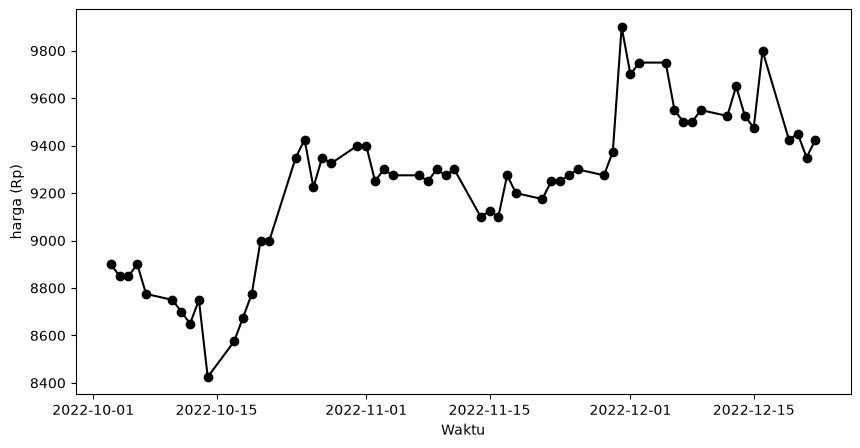

In [19]:
#menampilkan plot deret waktu
plt.figure(figsize=(10,5))
plt.plot(bni.Date,bni.Close,'-ok')
plt.xlabel('Waktu'), plt.ylabel('harga (Rp)')
plt.show()

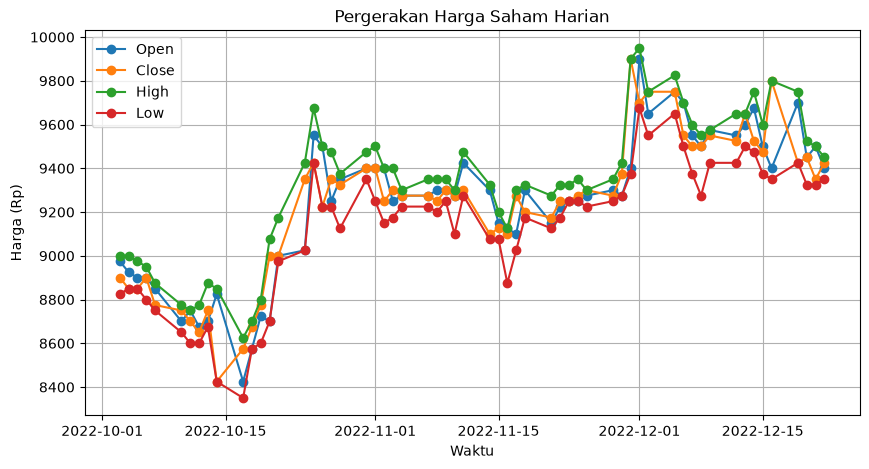

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(bni.Date, bni.Open, '-o',label='Open')
plt.plot(bni.Date, bni.Close, '-o',label='Close')
plt.plot(bni.Date, bni.High,'-o', label='High')
plt.plot(bni.Date, bni.Low, '-o',label='Low')

plt.xlabel('Waktu')
plt.ylabel('Harga (Rp)')
plt.title('Pergerakan Harga Saham Harian')
plt.legend()
plt.grid(True)

plt.show()

Apa yang dapat Anda interpretasikan dari plot tersebut?

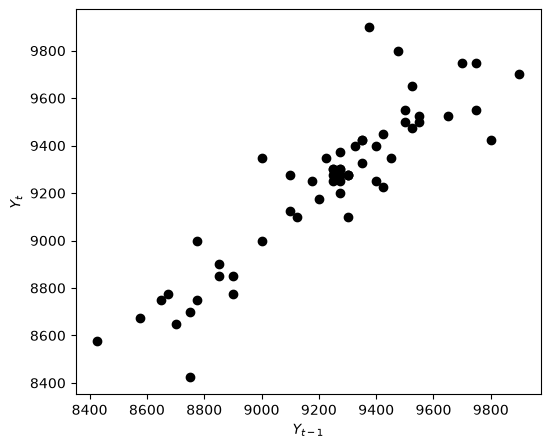

In [26]:
#menampilkan scatterplot antara Yt dan Yt-1
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=1, c='k')
plt.xlabel(r'$Y_{t-1}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Apa makna/interpretasi dari scatterplot yang diperoleh?

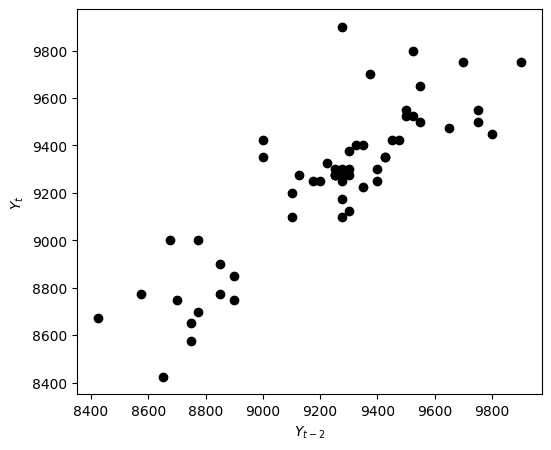

In [ ]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=2, c='k')
plt.xlabel(r'$Y_{t-2}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Bagaimana interpretasi plot scatterplot tersebut?

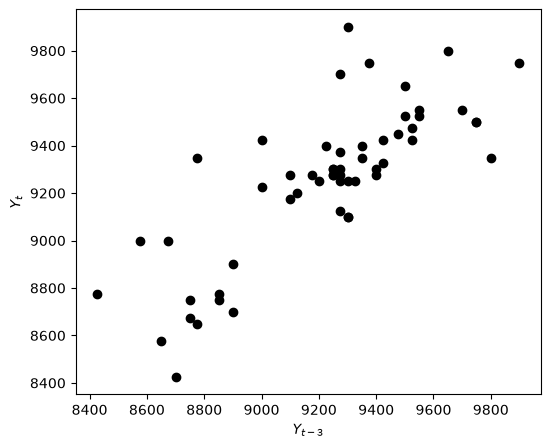

In [27]:
#menampilkan scatterplot antara Yt dan Yt-3
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=3, c='k')
plt.xlabel(r'$Y_{t-3}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

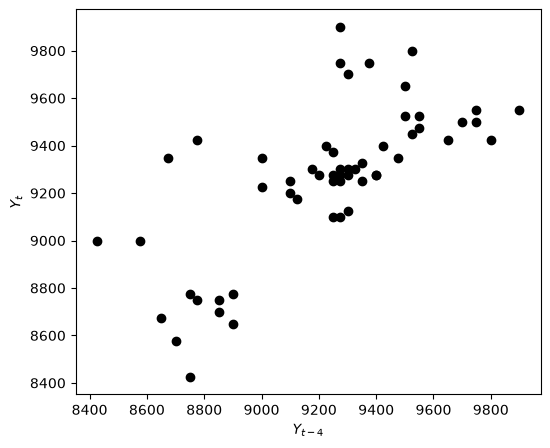

In [28]:
#menampilkan scatterplot antara Yt dan Yt-4
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=4, c='k')
plt.xlabel(r'$Y_{t-4}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

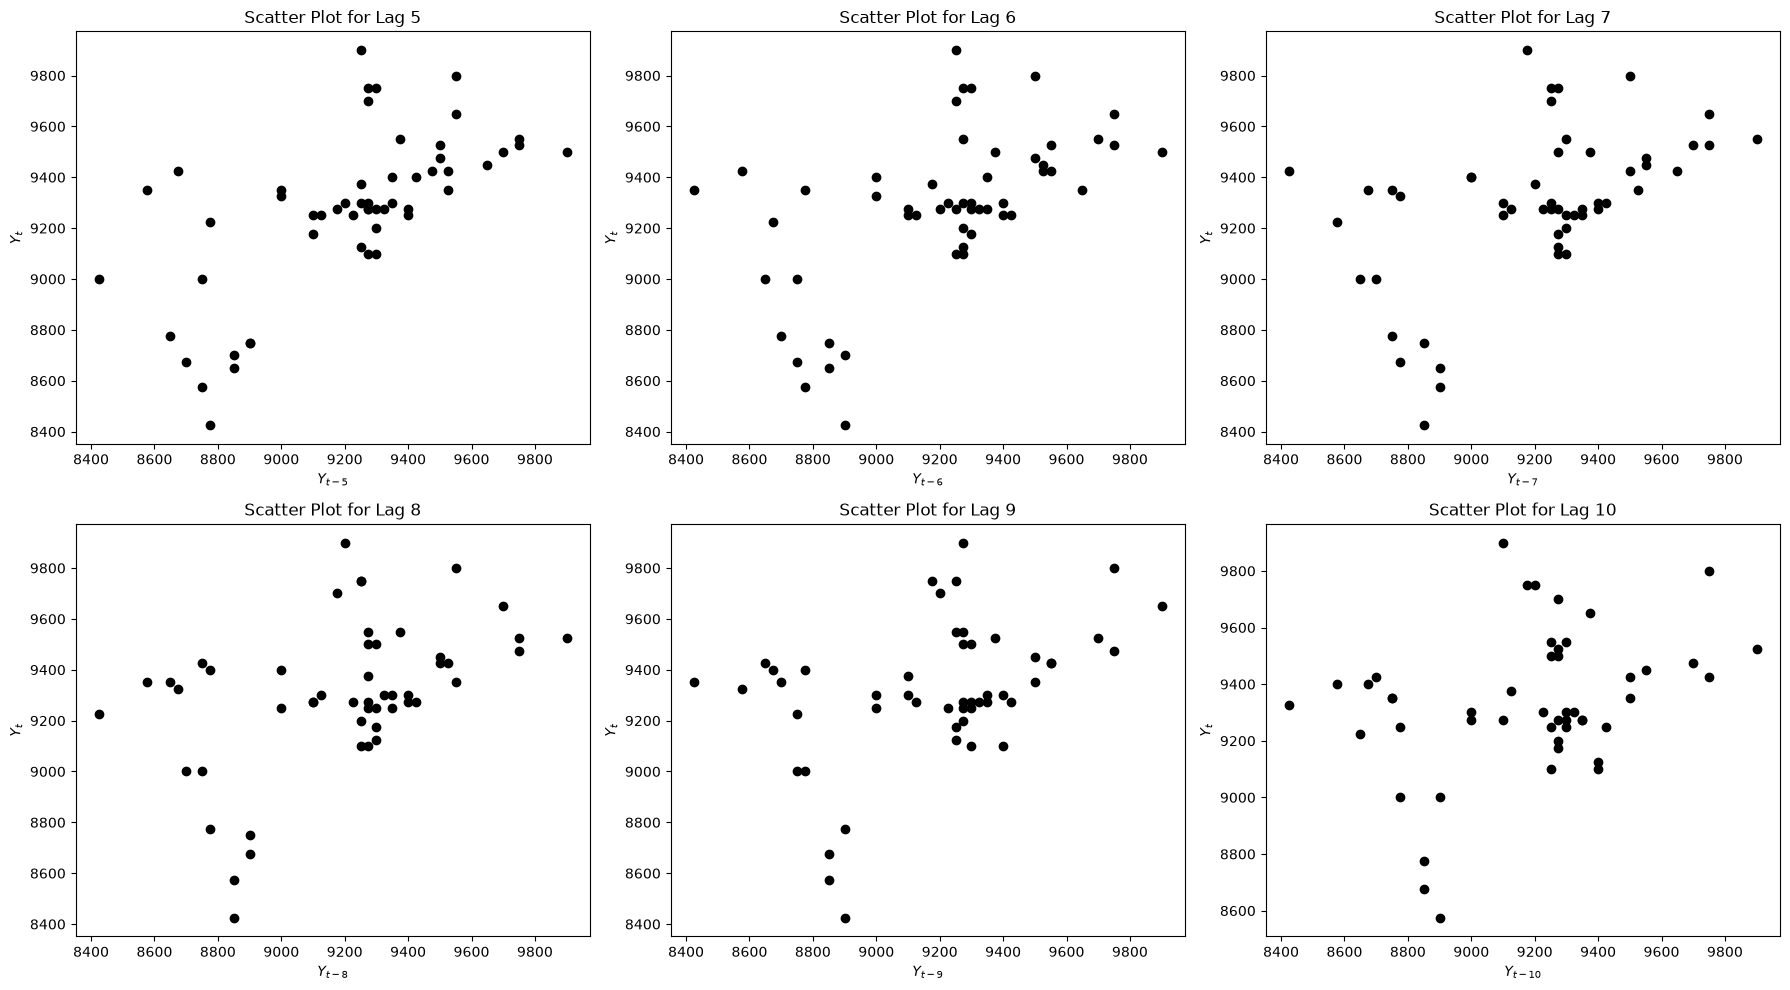

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

lags = range(5, 11)

for i, lag in enumerate(lags):
    ax = axes[i]
    pd.plotting.lag_plot(bni.Close, lag=lag, ax=ax, c='k')
    ax.set_xlabel(f'$Y_{{t-{lag}}}$')
    ax.set_ylabel(f'$Y_t$')
    ax.set_title(f'Scatter Plot for Lag {lag}')

plt.tight_layout()
plt.show()

Berdasarkan scatter plot $Y_t$ dengan lag 1 hingga 10, apa kesimpulan yang Anda peroleh?

## Pemulusan (_Smoothing_)

In [30]:
smoothing=pd.read_csv('https://raw.githubusercontent.com/lailynissaam/Analisis-Deret-Waktu/refs/heads/main/Sales.csv')

# Menghitung ukuran data
data_size = len(smoothing)

# Menghitung indeks untuk pembagian data latih dan data uji (75% untuk latih, 25% untuk uji)
train_size = int(data_size * 0.80)

# Membagi data menjadi data latih dan data uji
train_data_sma = smoothing.iloc[:train_size]
test_data_sma = smoothing.iloc[train_size:]

print(f"Ukuran data asli: {data_size}")
print(f"Ukuran data latih: {len(train_data_sma)}")
print(f"Ukuran data uji: {len(test_data_sma)}")

print("\n5 data latih pertama:")
print(train_data_sma.head())
print("\n5 data uji pertama:")
print(test_data_sma.head())

Ukuran data asli: 120
Ukuran data latih: 96
Ukuran data uji: 24

5 data latih pertama:
   Period    Sales
0       1  10618.1
1       2  10537.9
2       3  10209.3
3       4  10553.0
4       5   9934.9

5 data uji pertama:
     Period    Sales
96       97  10428.7
97       98  10615.8
98       99  10417.3
99      100  10445.4
100     101  10690.6


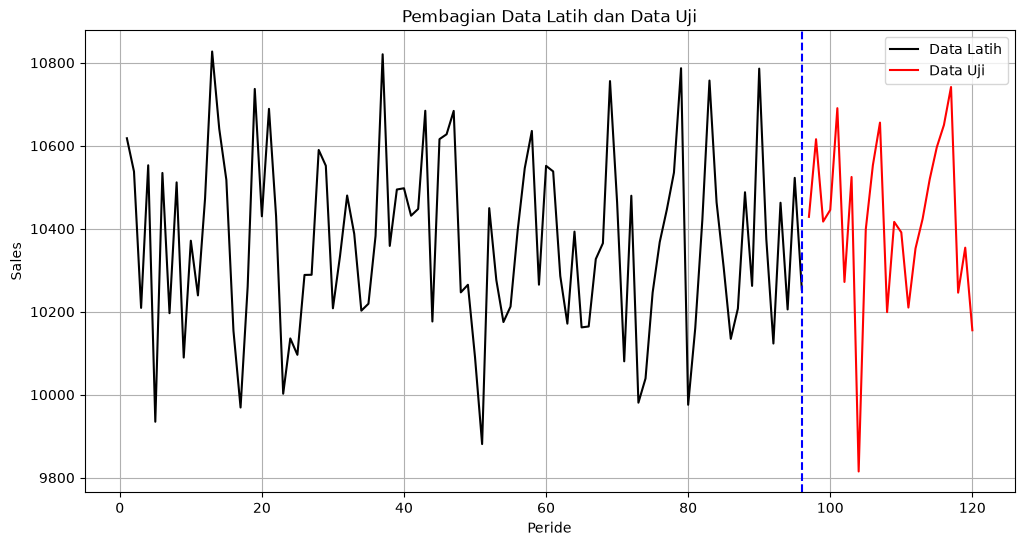

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(train_data_sma.Period, train_data_sma.Sales, color='black', label='Data Latih')
plt.plot(test_data_sma.Period, test_data_sma.Sales, color='red', label='Data Uji')

# Menambahkan garis vertikal pada titik pembagian
plt.axvline(x=train_data_sma.Period.iloc[-1], color='blue', linestyle='--')

plt.xlabel('Peride')
plt.ylabel('Sales')
plt.title('Pembagian Data Latih dan Data Uji')
plt.legend()
plt.grid(True)
plt.show()

### Single Moving Average (SMA)

Ide dasar dari Single Moving Average (SMA) adalah data suatu periode dipengaruhi oleh data periode sebelumnya. Metode pemulusan ini cocok digunakan untuk pola data stasioner atau konstan. Prinsip dasar metode pemulusan ini adalah data pemulusan pada periode ke-t merupakan rata rata dari m buah data pada periode ke-(t-m+1) hingga periode ke-t. Data pemulusan pada periode ke-t selanjutnya digunakan sebagai nilai peramalan pada periode ke t+1


   Period    Sales           SMA
0       1  10618.1           NaN
1       2  10537.9           NaN
2       3  10209.3  10455.100000
3       4  10553.0  10433.400000
4       5   9934.9  10232.400000
5       6  10534.5  10340.800000
6       7  10196.5  10221.966667
7       8  10511.8  10414.266667
8       9  10089.6  10265.966667
9      10  10371.2  10324.200000


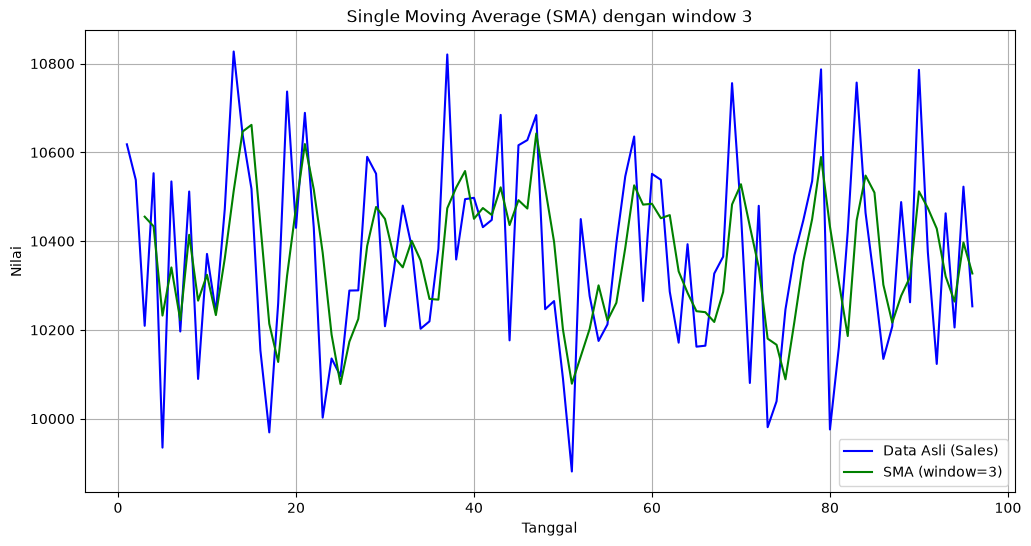

In [32]:
window = 3 # --> window atau nilai m

# Hitung Single Moving Average (SMA)
train_data_sma['SMA'] = train_data_sma['Sales'].rolling(window=window).mean()

# Tampilkan 10 data pertama dengan kolom SMA yang baru
print(train_data_sma.head(10))

# Plot data asli dan SMA
plt.figure(figsize=(12, 6))
plt.plot(train_data_sma.Period, train_data_sma.Sales, label='Data Asli (Sales)', color='blue')
plt.plot(train_data_sma.Period, train_data_sma['SMA'], label=f'SMA (window={window})', color='green')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.title(f'Single Moving Average (SMA) dengan window {window}')
plt.legend()
plt.grid(True)
plt.show()

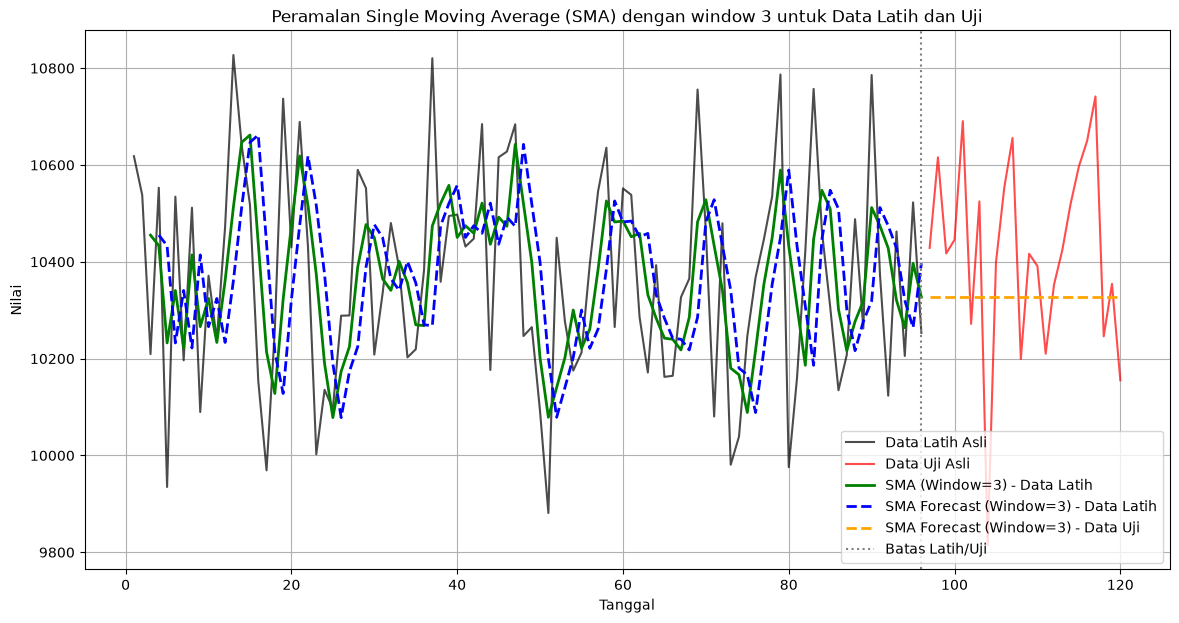

In [33]:
# Peramalah untuk data latih dilakukan dengan peramalan 1 periode ke depan
train_data_forecast= pd.Series(train_data_sma['SMA'].shift(1), index=train_data_sma.index)

# Untuk peramalan multi-langkah dengan SMA, pendekatan paling sederhana adalah
# memperpanjang nilai SMA terakhir dari data latih untuk seluruh periode uji.
if not train_data_sma['SMA'].empty:
    last_known_sma_from_train = train_data_sma['SMA'].iloc[-1]
else:
    # Tangani kasus jika data latih terlalu pendek untuk perhitungan SMA
    last_known_sma_from_train = np.nan # Atau penanganan error lainnya

test_data_forecast = pd.Series(last_known_sma_from_train, index=test_data_sma.index)

# 2. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_sma.Period, train_data_sma.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_sma.Period, test_data_sma.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot SMA untuk data latih (nilai yang dihaluskan)
plt.plot(train_data_sma.Period[~train_data_sma['SMA'].isnull()], train_data_sma['SMA'][~train_data_sma['SMA'].isnull()],
         label=f'SMA (Window={window}) - Data Latih', color='green', linestyle='-', linewidth=2)

# Plot nilai peramalan SMA untuk data latih dan data uji
plt.plot(train_data_sma.Period, train_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Latih', color='blue', linestyle='--', linewidth=2)
plt.plot(test_data_sma.Period, test_data_forecast,
         label=f'SMA Forecast (Window={window}) - Data Uji', color='orange', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_sma.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Single Moving Average (SMA) dengan window {window} untuk Data Latih dan Uji')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.0 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 2.0 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.2 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 2.0 MB/s eta 0:00:03
   --------------------- ------------------ 4.5/8.2 MB 2.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.2 MB 2.2 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.2 MB 2.3 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from sklearn.metrics import mean_squared_error

def calculate_rmse(actual, forecast):
    return np.sqrt(mean_squared_error(actual, forecast))

def calculate_mape(actual, forecast):
    # Filter out actual values that are zero to avoid division by zero
    non_zero_indices = actual != 0
    if not np.any(non_zero_indices):
        return np.nan # Or raise an error if all actual values are zero
    actual_filtered = actual[non_zero_indices]
    forecast_filtered = forecast[non_zero_indices]
    return np.mean(np.abs((actual_filtered - forecast_filtered) / actual_filtered)) * 100

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih ---")
# Hapus NaN dari forecast (karena SMA dan shift(1) menghasilkan NaN di awal)
actual_train_filtered = train_data_sma.loc[train_data_forecast.dropna().index, 'Sales']
forecast_train_filtered = train_data_forecast.dropna()

if not actual_train_filtered.empty:
    mse_train = mean_squared_error(actual_train_filtered, forecast_train_filtered)
    rmse_train = calculate_rmse(actual_train_filtered, forecast_train_filtered)
    mape_train = calculate_mape(actual_train_filtered, forecast_train_filtered)

    print(f"MSE (Train): {mse_train:.4f}")
    print(f"RMSE (Train): {rmse_train:.4f}")
    print(f"MAPE (Train): {mape_train:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji ---")
# Data uji sudah siap tanpa NaN yang perlu ditangani secara khusus
actual_test = test_data_sma['Sales']
forecast_test = test_data_forecast

if not actual_test.empty:
    mse_test = mean_squared_error(actual_test, forecast_test)
    rmse_test = calculate_rmse(actual_test, forecast_test)
    mape_test = calculate_mape(actual_test, forecast_test)

    print(f"MSE (Test): {mse_test:.4f}")
    print(f"RMSE (Test): {rmse_test:.4f}")
    print(f"MAPE (Test): {mape_test:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian.")


--- Evaluasi Peramalan Data Latih ---
MSE (Train): 70132.0311
RMSE (Train): 264.8245
MAPE (Train): 2.0932%

--- Evaluasi Peramalan Data Uji ---
MSE (Test): 49629.0281
RMSE (Test): 222.7757
MAPE (Test): 1.7373%


### Double Moving Average (DMA)

Metode pemulusan Double Moving Average (DMA) pada dasarnya mirip dengan SMA. Namun demikian, metode ini lebih cocok digunakan untuk pola data trend. Proses pemulusan dengan rata rata dalam metode ini dilakukan sebanyak 2 kali.

In [39]:
window_dma = 3

train_size = int(data_size * 0.80)

# Membagi data menjadi data latih dan data uji
train_data_dma = smoothing.iloc[:train_size]
test_data_dma = smoothing.iloc[train_size:]

# 1. Hitung SMA1 (Single Moving Average pertama)
train_data_dma['SMA1'] = train_data_dma['Sales'].rolling(window=window_dma).mean()

# 2. Hitung SMA2 (Single Moving Average kedua pada SMA1)
train_data_dma['SMA2'] = train_data_dma['SMA1'].rolling(window=window_dma).mean()

# 3. Hitung komponen level (A) dan trend (B) untuk DMA
train_data_dma['DMA_A'] = 2 * train_data_dma['SMA1'] - train_data_dma['SMA2']
# Rumus B_t = (SMA1_t - SMA2_t) * (2 / (window - 1))
# Untuk window=3, (2 / (3 - 1)) = 1
train_data_dma['DMA_B'] = train_data_dma['SMA1'] - train_data_dma['SMA2']

train_data_dma['DMA_final'] = (train_data_dma['DMA_A'] + train_data_dma['DMA_B'])

# Tampilkan 10 data pertama dengan kolom SMA yang baru
print(train_data_dma.head(10))

   Period    Sales          SMA1          SMA2         DMA_A       DMA_B  \
0       1  10618.1           NaN           NaN           NaN         NaN   
1       2  10537.9           NaN           NaN           NaN         NaN   
2       3  10209.3  10455.100000           NaN           NaN         NaN   
3       4  10553.0  10433.400000           NaN           NaN         NaN   
4       5   9934.9  10232.400000  10373.633333  10091.166667 -141.233333   
5       6  10534.5  10340.800000  10335.533333  10346.066667    5.266667   
6       7  10196.5  10221.966667  10265.055556  10178.877778  -43.088889   
7       8  10511.8  10414.266667  10325.677778  10502.855556   88.588889   
8       9  10089.6  10265.966667  10300.733333  10231.200000  -34.766667   
9      10  10371.2  10324.200000  10334.811111  10313.588889  -10.611111   

      DMA_final  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4   9949.933333  
5  10351.333333  
6  10135.788889  
7  10591.444444  
8

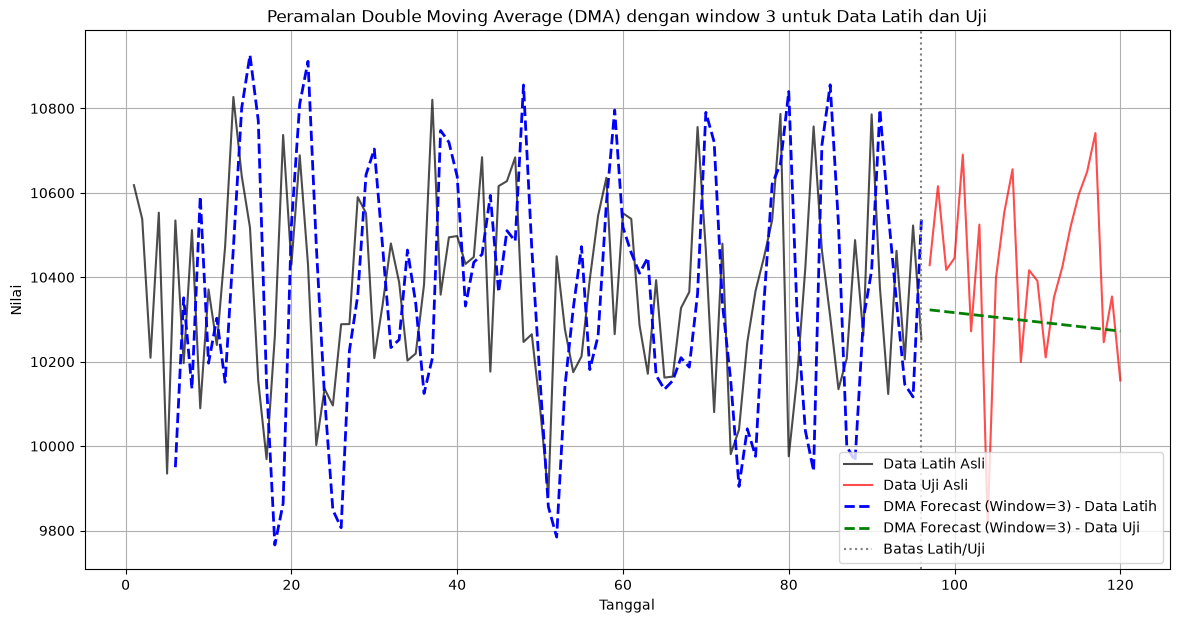

In [40]:
# 4. Peramalan untuk Data Latih (1-langkah ke depan)
# Forecast F_{t+1} = A_t + B_t * 1
train_dma_forecast = (train_data_dma['DMA_A'] + train_data_dma['DMA_B']).shift(1)

# 5. Peramalan untuk Data Uji (multi-langkah ke depan)
# Ambil A dan B terakhir dari data latih yang sudah dihitung DMA
last_dma_a = train_data_dma['DMA_A'].iloc[-1]
last_dma_b = train_data_dma['DMA_B'].iloc[-1]

test_dma_forecast_values = []
for k in range(1, len(test_data_dma) + 1):
    forecast_k = last_dma_a + k * last_dma_b
    test_dma_forecast_values.append(forecast_k)

test_dma_forecast = pd.Series(test_dma_forecast_values, index=test_data_dma.index)

# 6. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_dma.Period, train_data_dma.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_dma.Period, test_data_dma.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot DMA Forecast untuk data latih
# Filter NaN values for plotting DMA forecast on train data
valid_train_forecast_indices = train_dma_forecast.dropna().index
plt.plot(train_data_dma.loc[valid_train_forecast_indices, 'Period'], train_dma_forecast.dropna(),
         label=f'DMA Forecast (Window={window_dma}) - Data Latih', color='blue', linestyle='--', linewidth=2)

# Plot DMA Forecast untuk data uji
plt.plot(test_data_dma.Period, test_dma_forecast,
         label=f'DMA Forecast (Window={window_dma}) - Data Uji', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_dma.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Double Moving Average (DMA) dengan window {window_dma} untuk Data Latih dan Uji')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# 7. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (DMA) ---")
# Ambil data aktual dan peramalan yang tidak NaN
actual_train_dma_filtered = train_data_dma.loc[train_dma_forecast.dropna().index, 'Sales']
forecast_train_dma_filtered = train_dma_forecast.dropna()

if not actual_train_dma_filtered.empty and not forecast_train_dma_filtered.empty:
    mse_train_dma = mean_squared_error(actual_train_dma_filtered, forecast_train_dma_filtered)
    rmse_train_dma = calculate_rmse(actual_train_dma_filtered, forecast_train_dma_filtered)
    mape_train_dma = calculate_mape(actual_train_dma_filtered, forecast_train_dma_filtered)

    print(f"MSE (Train DMA): {mse_train_dma:.4f}")
    print(f"RMSE (Train DMA): {rmse_train_dma:.4f}")
    print(f"MAPE (Train DMA): {mape_train_dma:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan DMA.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (DMA) ---")
actual_test_dma = test_data_dma['Sales']
forecast_test_dma = test_dma_forecast

if not actual_test_dma.empty and not forecast_test_dma.empty:
    mse_test_dma = mean_squared_error(actual_test_dma, forecast_test_dma)
    rmse_test_dma = calculate_rmse(actual_test_dma, forecast_test_dma)
    mape_test_dma = calculate_mape(actual_test_dma, forecast_test_dma)

    print(f"MSE (Test DMA): {mse_test_dma:.4f}")
    print(f"RMSE (Test DMA): {rmse_test_dma:.4f}")
    print(f"MAPE (Test DMA): {mape_test_dma:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian DMA.")


--- Evaluasi Peramalan Data Latih (DMA) ---
MSE (Train DMA): 117017.6890
RMSE (Train DMA): 342.0785
MAPE (Train DMA): 2.6678%

--- Evaluasi Peramalan Data Uji (DMA) ---
MSE (Test DMA): 55878.4903
RMSE (Test DMA): 236.3863
MAPE (Test DMA): 1.8543%


### Single Exponential Smoothing

Metode *Exponential Smoothing* adalah metode pemulusan dengan melakukan pembobotan menurun secara eksponensial. Nilai yang lebih baru diberi bobot yang lebih besar dari nilai terdahulu. Terdapat satu atau lebih parameter pemulusan yang ditentukan secara eksplisit, dan hasil pemilihan parameter tersebut akan menentukan bobot yang akan diberikan pada nilai pengamatan. Ada dua macam model, yaitu model tunggal dan ganda.

Single Exponential Smoothing merupakan metode pemulusan yang tepat digunakan untuk data dengan pola stasioner atau konstan.

Nilai pemulusan pada periode ke-t didapat dari persamaan:

$$
\tilde{y}_t=\lambda y_t+(1-\lambda)\tilde{y}_{t-1}
$$

Nilai parameter $\lambda$ adalah nilai antara 0 dan 1.

Nilai pemulusan periode ke-t bertindak sebagai nilai ramalan pada periode ke-$(t+\tau)$.

$$
\tilde{y}_{t+\tau}(t)=\tilde{y}_t
$$


In [42]:
# 1. Tentukan parameter smoothing alpha
alpha = 0.3 # Anda bisa menyesuaikan nilai alpha (antara 0 dan 1)

# Membagi data menjadi data latih dan data uji
train_data_ses = smoothing.iloc[:train_size]
test_data_ses = smoothing.iloc[train_size:]

# 2. Hitung Single Exponential Smoothing (SES) pada data latih
# adjust=False: Menggunakan rumus rekursif SES langsung
# min_periods: Jumlah minimum observasi untuk memiliki hasil non-NaN (sesuai definisi SES)
train_data_ses['SES'] = train_data_ses['Sales'].ewm(alpha=alpha, adjust=False, min_periods=1).mean()

train_data_ses.head(10)

,Period,Sales,SES
0,1,10618.1,10618.100000
1,2,10537.9,10594.040000
2,3,10209.3,10478.618000
3,4,10553.0,10500.932600
4,5,9934.9,10331.122820
5,6,10534.5,10392.135974
6,7,10196.5,10333.445182
7,8,10511.8,10386.951627
8,9,10089.6,10297.746139
9,10,10371.2,10319.782297


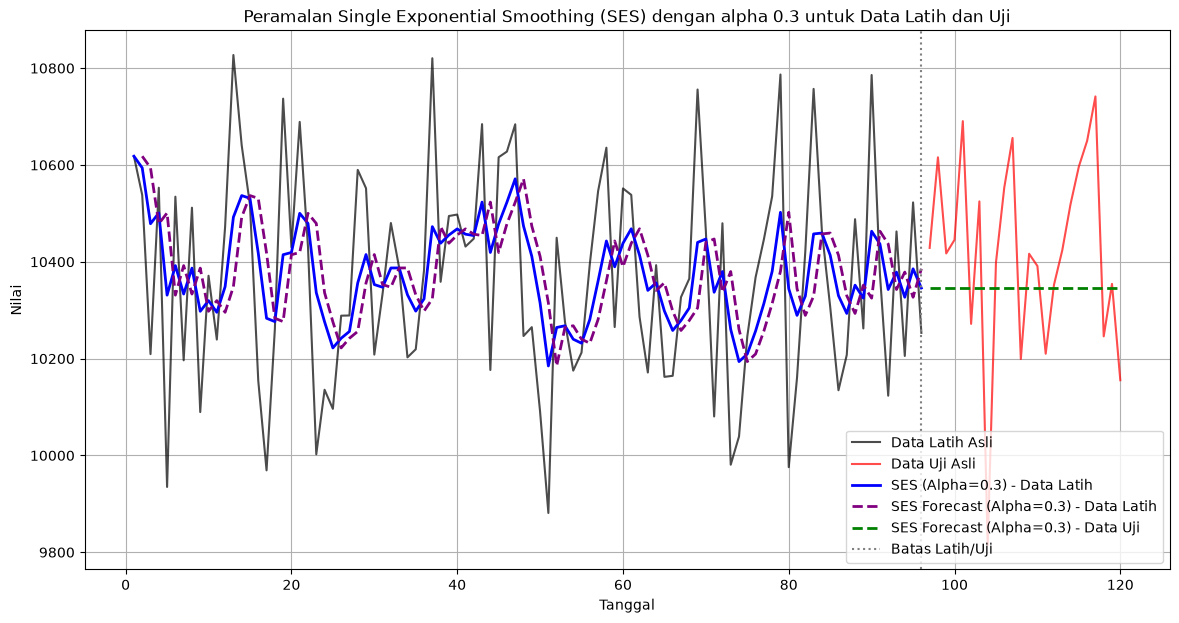

In [43]:
# 3. Peramalan untuk Data Latih (1-langkah ke depan)
# Peramalan untuk periode t+1 adalah nilai smoothed pada periode t
train_ses_forecast = train_data_ses['SES'].shift(1)

# 4. Peramalan untuk Data Uji (multi-langkah ke depan)
# Nilai peramalan untuk seluruh periode uji adalah nilai SES terakhir dari data latih
if not train_data_ses['SES'].empty:
    last_ses_from_train = train_data_ses['SES'].iloc[-1]
else:
    last_ses_from_train = np.nan

test_ses_forecast = pd.Series(last_ses_from_train, index=test_data_ses.index)

# 5. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_ses.Period, train_data_ses.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_ses.Period, test_data_ses.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot SES untuk data latih (nilai yang dihaluskan)
plt.plot(train_data_ses.Period[~train_data_ses['SES'].isnull()], train_data_ses['SES'][~train_data_ses['SES'].isnull()],
         label=f'SES (Alpha={alpha}) - Data Latih', color='blue', linestyle='-', linewidth=2)

# Plot nilai peramalan SES untuk data latih
plt.plot(train_data_ses.Period, train_ses_forecast,
         label=f'SES Forecast (Alpha={alpha}) - Data Latih', color='purple', linestyle='--', linewidth=2)

# Plot nilai peramalan SES untuk data uji
plt.plot(test_data_ses.Period, test_ses_forecast,
         label=f'SES Forecast (Alpha={alpha}) - Data Uji', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_ses.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title(f'Peramalan Single Exponential Smoothing (SES) dengan alpha {alpha} untuk Data Latih dan Uji')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# 6. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (SES) ---")
# Ambil data aktual dan peramalan yang tidak NaN (karena shift(1))
actual_train_ses_filtered = train_data_ses.loc[train_ses_forecast.dropna().index, 'Sales']
forecast_train_ses_filtered = train_ses_forecast.dropna()

if not actual_train_ses_filtered.empty and not forecast_train_ses_filtered.empty:
    mse_train_ses = mean_squared_error(actual_train_ses_filtered, forecast_train_ses_filtered)
    rmse_train_ses = calculate_rmse(actual_train_ses_filtered, forecast_train_ses_filtered)
    mape_train_ses = calculate_mape(actual_train_ses_filtered, forecast_train_ses_filtered)

    print(f"MSE (Train SES): {mse_train_ses:.4f}")
    print(f"RMSE (Train SES): {rmse_train_ses:.4f}")
    print(f"MAPE (Train SES): {mape_train_ses:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan SES.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (SES) ---")
actual_test_ses = test_data_ses['Sales']
forecast_test_ses = test_ses_forecast

if not actual_test_ses.empty and not forecast_test_ses.empty:
    mse_test_ses = mean_squared_error(actual_test_ses, forecast_test_ses)
    rmse_test_ses = calculate_rmse(actual_test_ses, forecast_test_ses)
    mape_test_ses = calculate_mape(actual_test_ses, forecast_test_ses)

    print(f"MSE (Test SES): {mse_test_ses:.4f}")
    print(f"RMSE (Test SES): {rmse_test_ses:.4f}")
    print(f"MAPE (Test SES): {mape_test_ses:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian SES.")


--- Evaluasi Peramalan Data Latih (SES) ---
MSE (Train SES): 58593.2500
RMSE (Train SES): 242.0604
MAPE (Train SES): 1.9040%

--- Evaluasi Peramalan Data Uji (SES) ---
MSE (Test SES): 46511.7955
RMSE (Test SES): 215.6659
MAPE (Test SES): 1.6498%


### Double Exponential Smoothing

Metode pemulusan *Double Exponential Smoothing* (DES) digunakan untuk data yang memiliki pola tren. Metode DES adalah metode semacam SES, hanya saja dilakukan dua kali, yaitu pertama untuk tahapan 'level' dan kedua untuk tahapan 'tren'. Pemulusan menggunakan metode ini akan menghasilkan peramalan tidak konstan untuk periode berikutnya.


In [46]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.3 MB 2.1 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.3 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.3 MB 2.1 MB/s eta 0:00:05
   --------- ------------------------------ 2.6/11.3 MB 2.1 MB/s eta 0:00:05
   ---------- ----------------------------- 2.9/11.3 MB 2.1 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/11.3 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.9/11.3 MB 2.1 MB/s eta 0:00:04
   -------------- ------------------------- 4.2/11.3 MB 2.1 MB/s eta 0:00:04
   ---------------- ----------------------- 4.7/11.3 MB 2.1 MB/s eta 0:00:04
   ----------------- ---------------------- 5.0/11.3 MB 2.1 MB/s eta 0:00:04
   ----------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


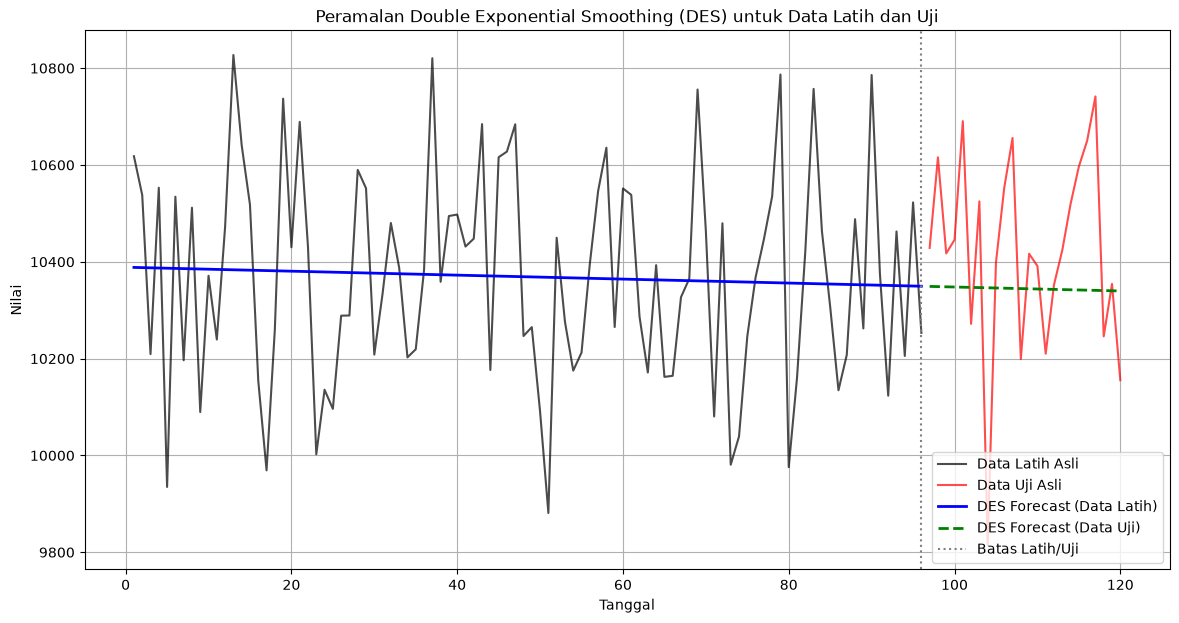

In [47]:
from statsmodels.tsa.api import ExponentialSmoothing

# 1. Membagi data menjadi data latih dan data uji untuk DES
# Menggunakan variabel train_size yang sudah didefinisikan sebelumnya
train_data_des = smoothing.iloc[:train_size].copy()
test_data_des = smoothing.iloc[train_size:].copy()

# 2. Lakukan Double Exponential Smoothing (DES) pada data latih
# model dengan trend='add' (additive trend) untuk Double Exponential Smoothing
# initialization_method='estimated' agar statsmodels mengestimasi parameter awal secara otomatis
model_des = ExponentialSmoothing(
    train_data_des['Sales'],
    trend='add',
    seasonal=None,
    seasonal_periods=None,
    initialization_method='estimated'
).fit()

# Dapatkan nilai peramalan in-sample (fitted values) untuk data latih
train_des_forecast = model_des.fittedvalues

# 3. Peramalan untuk Data Uji (multi-langkah ke depan)
# Menggunakan metode forecast() dari model yang sudah fit
test_des_forecast = model_des.forecast(len(test_data_des))

# 4. Plot hasil peramalan
plt.figure(figsize=(14, 7))

# Plot data asli (latih dan uji)
plt.plot(train_data_des.Period, train_data_des.Sales, label='Data Latih Asli', color='black', alpha=0.7)
plt.plot(test_data_des.Period, test_data_des.Sales, label='Data Uji Asli', color='red', alpha=0.7)

# Plot peramalan DES untuk data latih
plt.plot(train_data_des.Period, train_des_forecast,
         label='DES Forecast (Data Latih)', color='blue', linestyle='-', linewidth=2)

# Plot peramalan DES untuk data uji
plt.plot(test_data_des.Period, test_des_forecast,
         label='DES Forecast (Data Uji)', color='green', linestyle='--', linewidth=2)

# Tambahkan garis vertikal sebagai penanda batas data latih/uji
plt.axvline(x=train_data_des.Period.iloc[-1], color='grey', linestyle=':', label='Batas Latih/Uji')

plt.title('Peramalan Double Exponential Smoothing (DES) untuk Data Latih dan Uji')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# 5. Hitung metrik evaluasi (MSE, RMSE, MAPE)

# --- Evaluasi Data Latih ---
print("\n--- Evaluasi Peramalan Data Latih (DES) ---")
actual_train_des_filtered = train_data_des['Sales']
forecast_train_des_filtered = train_des_forecast

if not actual_train_des_filtered.empty and not forecast_train_des_filtered.empty:
    mse_train_des = mean_squared_error(actual_train_des_filtered, forecast_train_des_filtered)
    rmse_train_des = calculate_rmse(actual_train_des_filtered, forecast_train_des_filtered)
    mape_train_des = calculate_mape(actual_train_des_filtered, forecast_train_des_filtered)

    print(f"MSE (Train DES): {mse_train_des:.4f}")
    print(f"RMSE (Train DES): {rmse_train_des:.4f}")
    print(f"MAPE (Train DES): {mape_train_des:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pelatihan DES.")

# --- Evaluasi Data Uji ---
print("\n--- Evaluasi Peramalan Data Uji (DES) ---")
actual_test_des = test_data_des['Sales']
forecast_test_des = test_des_forecast

if not actual_test_des.empty and not forecast_test_des.empty:
    mse_test_des = mean_squared_error(actual_test_des, forecast_test_des)
    rmse_test_des = calculate_rmse(actual_test_des, forecast_test_des)
    mape_test_des = calculate_mape(actual_test_des, forecast_test_des)

    print(f"MSE (Test DES): {mse_test_des:.4f}")
    print(f"RMSE (Test DES): {rmse_test_des:.4f}")
    print(f"MAPE (Test DES): {mape_test_des:.4f}%")
else:
    print("Tidak cukup data valid untuk menghitung metrik pengujian DES.")


--- Evaluasi Peramalan Data Latih (DES) ---
MSE (Train DES): 47689.8768
RMSE (Train DES): 218.3801
MAPE (Train DES): 1.7536%

--- Evaluasi Peramalan Data Uji (DES) ---
MSE (Test DES): 46667.7122
RMSE (Test DES): 216.0271
MAPE (Test DES): 1.6524%
